# CIFAR-10 Warm-Start Regularizer Verification

This notebook checks whether the warm-started CIFAR-10 SIREN experiments actually moved the model toward the intended constraints.

It verifies:

- exact spectral norms for the SIREN sine layers and the RGB readout
- spectral-cap penalties for the readout, final sine layer, and counter-amplification variants
- orthogonality penalties for the orthogonal run
- layer-by-layer signal amplification through the SIREN, using both a Lipschitz-style bound and actual activation statistics

The calculations use exact SVDs on the saved checkpoints, not the noisy power-iteration estimate used during training.

In [1]:
from pathlib import Path
import math
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path('/home/omarg/SIREN_Vista')
sys.path.insert(0, str(ROOT))

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.precision', 6)

OUT_DIR = ROOT / 'runs' / 'diagnostics' / 'cifar10_warmstart_regularizer_verification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_CKPT = 'model_cifar10/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000/modSiren.pth'

MODELS = [
    dict(label='vanilla_base', relpath=BASE_CKPT, group='reference'),
    dict(label='softlip_tiered_e12', relpath='model_cifar10/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/modSiren.pth', group='baseline_softlip'),
    dict(label='warm_orth_lam1e-3', relpath='model_cifar10/cifar10_spatial_warmvanilla_orth_sine_and_readout_auto_lam1e-3/modSiren.pth', group='warm_orthogonal'),
    dict(label='warm_readout_cap90_lam1', relpath='model_cifar10/cifar10_spatial_warmvanilla_readout_cap90_lam1.0/modSiren.pth', group='warm_spectral_cap'),
    dict(label='warm_readout_cap50_lam1', relpath='model_cifar10/cifar10_spatial_warmvanilla_readout_cap50_lam1.0/modSiren.pth', group='warm_spectral_cap'),
    dict(label='warm_readout_cap10_lam1', relpath='model_cifar10/cifar10_spatial_warmvanilla_readout_cap10_lam1.0/modSiren.pth', group='warm_spectral_cap'),
    dict(label='warm_prereadout_cap10_lam1', relpath='model_cifar10/cifar10_spatial_warmvanilla_prereadout_cap10_lam1.0/modSiren.pth', group='warm_spectral_cap'),
    dict(label='warm_readout_counter1_lam1e-2', relpath='model_cifar10/cifar10_spatial_warmvanilla_readout_counter1.0_lam1e-2/modSiren.pth', group='warm_counter_cap'),
    dict(label='warm_prereadout_counter1_lam1e-2', relpath='model_cifar10/cifar10_spatial_warmvanilla_prereadout_counter1.0_lam1e-2/modSiren.pth', group='warm_counter_cap'),
]

for spec in MODELS:
    path = ROOT / spec['relpath']
    if not path.exists():
        print('missing:', path)
    else:
        print('found:', spec['label'])

found: vanilla_base
found: softlip_tiered_e12
found: warm_orth_lam1e-3
found: warm_readout_cap90_lam1
found: warm_readout_cap50_lam1
found: warm_readout_cap10_lam1
found: warm_prereadout_cap10_lam1
found: warm_readout_counter1_lam1e-2
found: warm_prereadout_counter1_lam1e-2


In [2]:
def load_checkpoint(relpath):
    ckpt = torch.load(ROOT / relpath, map_location='cpu')
    state = ckpt.get('state_dict', ckpt)
    return ckpt, state


def exact_sigma(weight):
    W = weight.detach().float().reshape(weight.shape[0], -1)
    return float(torch.linalg.svdvals(W)[0].item())


def sine_weight_keys(state):
    keys = []
    idx = 0
    while f'siren.net.{idx}.affine.weight' in state:
        keys.append(f'siren.net.{idx}.affine.weight')
        idx += 1
    return keys


def model_freq(ckpt):
    return float(ckpt.get('model_args', {}).get('freq', 10.0))


def reference_stats(reference_relpath=BASE_CKPT):
    ckpt, state = load_checkpoint(reference_relpath)
    keys = sine_weight_keys(state)
    sigmas = {key: exact_sigma(state[key]) for key in keys}
    sigmas['siren.hidden2rgb.weight'] = exact_sigma(state['siren.hidden2rgb.weight'])
    freqs = [model_freq(ckpt) for _ in keys]
    return dict(ckpt=ckpt, state=state, sine_keys=keys, sigmas=sigmas, freqs=freqs)


REF = reference_stats()
print('vanilla readout sigma:', REF['sigmas']['siren.hidden2rgb.weight'])
print('vanilla final sine sigma:', REF['sigmas'][REF['sine_keys'][-1]])

vanilla readout sigma: 0.18244318664073944
vanilla final sine sigma: 0.6127501726150513


In [3]:
def orth_penalty_for_weight(weight, form='auto'):
    W = weight.detach().float().reshape(weight.shape[0], -1)
    out_dim, in_dim = W.shape
    if form == 'auto':
        use_columns = out_dim >= in_dim
    elif form == 'columns':
        use_columns = True
    elif form == 'rows':
        use_columns = False
    else:
        raise ValueError(form)
    gram = W.T @ W if use_columns else W @ W.T
    eye = torch.eye(gram.shape[0], dtype=gram.dtype)
    return float(((gram - eye) ** 2).mean().item())


def cap_from_spectral_args(args, target):
    ref_relpath = args.get('spec_cap_reference_checkpoint') or BASE_CKPT
    if str(ref_relpath).startswith(str(ROOT)):
        ref_relpath = str(Path(ref_relpath).relative_to(ROOT))
    ref = reference_stats(ref_relpath)

    if args.get('spec_cap_absolute') is not None:
        return float(args['spec_cap_absolute'])

    mode = args.get('spec_cap_mode', 'reference_scale')
    if mode == 'reference_scale':
        scale = float(args.get('spec_cap_scale', 0.9))
        key = 'siren.hidden2rgb.weight' if target == 'readout' else ref['sine_keys'][-1]
        return ref['sigmas'][key] * scale

    if mode == 'counter_amplification':
        target_total = float(args.get('spec_cap_counter_target', 1.0))
        readout_sigma = ref['sigmas']['siren.hidden2rgb.weight']
        if target == 'readout':
            sine_amp = 1.0
            for key, freq in zip(ref['sine_keys'], ref['freqs']):
                sine_amp *= max(freq * ref['sigmas'][key], 1e-12)
            return target_total / max(sine_amp, 1e-12)
        if target == 'pre_readout':
            prev_amp = 1.0
            for key, freq in zip(ref['sine_keys'][:-1], ref['freqs'][:-1]):
                prev_amp *= max(freq * ref['sigmas'][key], 1e-12)
            denom = max(readout_sigma * prev_amp * ref['freqs'][-1], 1e-12)
            return target_total / denom

    raise ValueError(args)


def softlip_tiered_caps_from_vanilla():
    # This is the CIFAR tiered preset documented in context/cifar10_softlip_current_update.md.
    # Sine ratios: 90%, 85%, 85%, then 75% on later sine layers.
    # The run name is sine_and_readout, and the observed readout target is consistent with an 80% cap.
    ratios = [0.90, 0.85, 0.85, 0.75, 0.75, 0.75]
    caps = {}
    for idx, key in enumerate(REF['sine_keys']):
        caps[f'sine.{idx}'] = REF['sigmas'][key] * ratios[idx]
    caps['readout'] = REF['sigmas']['siren.hidden2rgb.weight'] * 0.80
    return caps


def spectral_cap_layer_terms(label, ckpt, state):
    args = ckpt.get('variant_args', {}) or {}
    keys = sine_weight_keys(state)

    if ckpt.get('variant') == 'soft_lipschitz' and args.get('soft_lip_cap_preset') == 'cifar_spatial_tiered':
        caps = softlip_tiered_caps_from_vanilla()
        rows = []
        for idx, key in enumerate(keys):
            name = f'sine.{idx}'
            cur = exact_sigma(state[key])
            cap = caps[name]
            violation = max(cur - cap, 0.0)
            rows.append(dict(model=label, target_layer=name, sigma=cur, cap=cap, sigma_over_cap=cur / cap, violation=violation, raw_term=violation ** 2))
        cur = exact_sigma(state['siren.hidden2rgb.weight'])
        cap = caps['readout']
        violation = max(cur - cap, 0.0)
        rows.append(dict(model=label, target_layer='readout', sigma=cur, cap=cap, sigma_over_cap=cur / cap, violation=violation, raw_term=violation ** 2))
        return rows, float(args.get('soft_lip_lambda', 0.01))

    if ckpt.get('variant') != 'spectral_cap':
        return [], None

    target = args.get('spec_cap_target', 'readout')
    targets = ['pre_readout', 'readout'] if target == 'readout_and_pre_readout' else [target]
    rows = []
    for target in targets:
        if target == 'readout':
            name = 'readout'
            key = 'siren.hidden2rgb.weight'
        else:
            name = f'sine.{len(keys) - 1}'
            key = keys[-1]
        cur = exact_sigma(state[key])
        cap = cap_from_spectral_args(args, target)
        violation = max(cur - cap, 0.0)
        rows.append(dict(model=label, target_layer=name, sigma=cur, cap=cap, sigma_over_cap=cur / cap, violation=violation, raw_term=violation ** 2))
    return rows, float(args.get('spec_cap_lambda', 1e-2))


def orth_layer_terms(label, ckpt, state):
    if ckpt.get('variant') != 'orthogonal':
        return [], None
    args = ckpt.get('variant_args', {}) or {}
    mode = args.get('orth_apply_to', 'sine_only')
    form = args.get('orth_form', 'auto')
    skip_first = bool(args.get('orth_skip_first', False))
    keys = sine_weight_keys(state)
    rows = []
    for idx, key in enumerate(keys):
        if skip_first and idx == 0:
            continue
        rows.append(dict(model=label, target_layer=f'sine.{idx}', orth_form=form, raw_term=orth_penalty_for_weight(state[key], form=form)))
    if mode in ('sine_and_readout', 'all'):
        rows.append(dict(model=label, target_layer='readout', orth_form=form, raw_term=orth_penalty_for_weight(state['siren.hidden2rgb.weight'], form=form)))
    return rows, float(args.get('orth_lambda', 1e-3))

In [4]:
summary_rows = []
cap_rows = []
orth_rows = []
layer_rows = []

for spec in MODELS:
    label = spec['label']
    ckpt, state = load_checkpoint(spec['relpath'])
    keys = sine_weight_keys(state)
    freq = model_freq(ckpt)

    cumulative = 1.0
    for idx, key in enumerate(keys):
        sig = exact_sigma(state[key])
        effective_gain = freq * sig
        cumulative *= effective_gain
        layer_rows.append(dict(model=label, layer=f'sine.{idx}', sigma=sig, effective_gain=effective_gain, cumulative_bound=cumulative))
    readout_sigma = exact_sigma(state['siren.hidden2rgb.weight'])
    cumulative *= readout_sigma
    layer_rows.append(dict(model=label, layer='readout', sigma=readout_sigma, effective_gain=readout_sigma, cumulative_bound=cumulative))

    cap_terms, cap_lambda = spectral_cap_layer_terms(label, ckpt, state)
    orth_terms, orth_lambda = orth_layer_terms(label, ckpt, state)
    cap_rows.extend(cap_terms)
    orth_rows.extend(orth_terms)

    raw_cap = sum(row['raw_term'] for row in cap_terms) if cap_terms else np.nan
    raw_orth = sum(row['raw_term'] for row in orth_terms) if orth_terms else np.nan
    summary_rows.append(dict(
        model=label,
        group=spec['group'],
        checkpoint=spec['relpath'],
        variant=ckpt.get('variant'),
        epoch=ckpt.get('epoch'),
        loss=ckpt.get('loss'),
        final_product_bound=cumulative,
        cap_raw_penalty=raw_cap,
        cap_weighted_penalty=(cap_lambda * raw_cap) if cap_terms else np.nan,
        cap_max_violation=max([row['violation'] for row in cap_terms], default=np.nan),
        orth_raw_penalty=raw_orth,
        orth_weighted_penalty=(orth_lambda * raw_orth) if orth_terms else np.nan,
        orth_max_layer_penalty=max([row['raw_term'] for row in orth_terms], default=np.nan),
    ))

summary_df = pd.DataFrame(summary_rows)
cap_df = pd.DataFrame(cap_rows)
orth_df = pd.DataFrame(orth_rows)
layer_df = pd.DataFrame(layer_rows)

summary_df.to_csv(OUT_DIR / 'regularizer_penalty_summary.csv', index=False)
cap_df.to_csv(OUT_DIR / 'spectral_cap_terms.csv', index=False)
orth_df.to_csv(OUT_DIR / 'orthogonality_terms.csv', index=False)
layer_df.to_csv(OUT_DIR / 'layerwise_lipschitz_amplification.csv', index=False)

summary_df[['model', 'variant', 'epoch', 'loss', 'cap_weighted_penalty', 'cap_max_violation', 'orth_weighted_penalty', 'orth_max_layer_penalty', 'final_product_bound']]

,model,variant,epoch,loss,cap_weighted_penalty,cap_max_violation,orth_weighted_penalty,orth_max_layer_penalty,final_product_bound
0,vanilla_base,vanilla,277,0.001266,NaN,NaN,NaN,NaN,28782.029037
1,softlip_tiered_e12,soft_lipschitz,57,0.001905,9.908890e-07,0.005932,NaN,NaN,6845.633883
2,warm_orth_lam1e-3,orthogonal,19,0.086606,NaN,NaN,0.082608,82.267181,22137.816771
3,warm_readout_cap90_lam1,spectral_cap,1,0.001221,1.152910e-07,0.000340,NaN,NaN,25249.299100
4,warm_readout_cap50_lam1,spectral_cap,19,0.001720,1.077017e-04,0.010378,NaN,NaN,15789.578802
5,warm_readout_cap10_lam1,spectral_cap,19,0.006318,4.116864e-03,0.064163,NaN,NaN,13283.702169
6,warm_prereadout_cap10_lam1,spectral_cap,19,0.001976,6.048844e-04,0.024594,NaN,NaN,6747.329953
7,warm_readout_counter1_lam1e-2,spectral_cap,10,0.001591,1.874663e-04,0.136918,NaN,NaN,20767.233516
8,warm_prereadout_counter1_lam1e-2,spectral_cap,19,0.001500,3.410205e-04,0.184667,NaN,NaN,10894.568529


## Spectral Cap Convergence

`sigma_over_cap <= 1` means the intended cap is satisfied. Values above `1` show how far the checkpoint still violates the cap.

In [5]:
cap_df.sort_values(['model', 'target_layer'])

,model,target_layer,sigma,cap,sigma_over_cap,violation,raw_term
6,softlip_tiered_e12,readout,0.151287,0.145955,1.036536,0.005333,2.843682e-05
0,softlip_tiered_e12,sine.0,4.479330,4.478670,1.000147,0.000659,4.347694e-07
1,softlip_tiered_e12,sine.1,0.365791,0.359858,1.016485,0.005932,3.519296e-05
2,softlip_tiered_e12,sine.2,0.467833,0.466646,1.002543,0.001187,1.408303e-06
3,softlip_tiered_e12,sine.3,0.349533,0.344974,1.013216,0.004559,2.078743e-05
4,softlip_tiered_e12,sine.4,0.366065,0.362960,1.008556,0.003105,9.643845e-06
5,softlip_tiered_e12,sine.5,0.461347,0.459563,1.003883,0.001785,3.184772e-06
10,warm_prereadout_cap10_lam1,sine.5,0.085869,0.061275,1.401377,0.024594,6.048844e-04
12,warm_prereadout_counter1_lam1e-2,sine.5,0.184689,0.000021,8675.179722,0.184667,3.410205e-02
9,warm_readout_cap10_lam1,readout,0.082407,0.018244,4.516864,0.064163,4.116864e-03


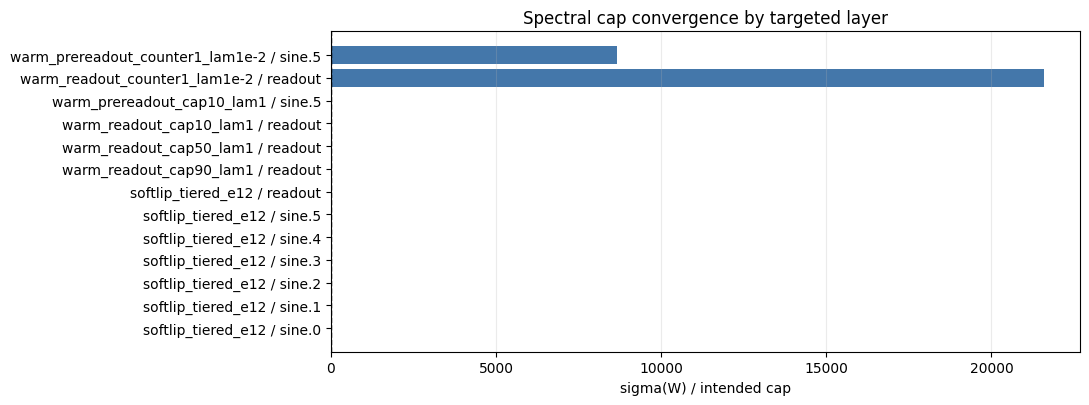

In [6]:
if not cap_df.empty:
    plot_df = cap_df.copy()
    plot_df['model_layer'] = plot_df['model'] + ' / ' + plot_df['target_layer']
    fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(plot_df))))
    ax.barh(plot_df['model_layer'], plot_df['sigma_over_cap'], color='#4477AA')
    ax.axvline(1.0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('sigma(W) / intended cap')
    ax.set_title('Spectral cap convergence by targeted layer')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'spectral_cap_convergence.png', dpi=180)
    plt.show()

## Orthogonality Convergence

The orthogonal run used `mean((G - I)^2)` per selected layer, with `G = W^T W` for tall/square layers and `G = W W^T` when the layer is wide. Lower is better. A value near zero means that layer is close to orthonormal under the selected form.

In [7]:
orth_df.sort_values(['model', 'target_layer'])

,model,target_layer,orth_form,raw_term
6,warm_orth_lam1e-3,readout,auto,0.321989
0,warm_orth_lam1e-3,sine.0,auto,82.267181
1,warm_orth_lam1e-3,sine.1,auto,0.003732
2,warm_orth_lam1e-3,sine.2,auto,0.003712
3,warm_orth_lam1e-3,sine.3,auto,0.003717
4,warm_orth_lam1e-3,sine.4,auto,0.003711
5,warm_orth_lam1e-3,sine.5,auto,0.003719


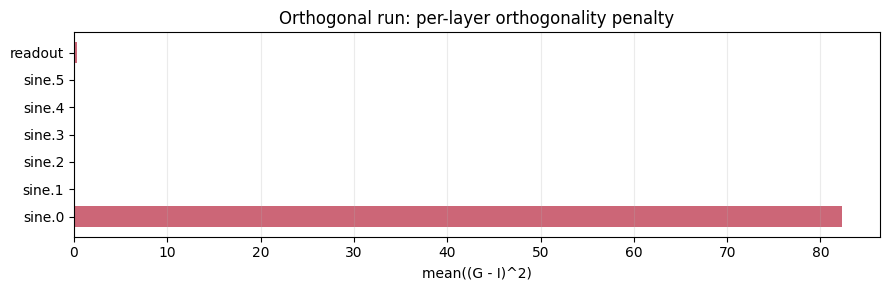

In [8]:
if not orth_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(orth_df))))
    ax.barh(orth_df['target_layer'], orth_df['raw_term'], color='#CC6677')
    ax.set_xlabel('mean((G - I)^2)')
    ax.set_title('Orthogonal run: per-layer orthogonality penalty')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'orthogonality_terms.png', dpi=180)
    plt.show()

## Lipschitz-Style Signal Amplification

For each sine layer, the local Lipschitz upper bound is `freq * sigma(W)`, because the layer is `sin(freq * (W x + b + shift))` and `|cos| <= 1`. The readout contributes `sigma(W_readout)`. The cumulative product is a worst-case upper bound, not the typical observed activation scale.

In [9]:
layer_df.sort_values(['model', 'layer'])

,model,layer,sigma,effective_gain,cumulative_bound
13,softlip_tiered_e12,readout,0.151287,0.151287,6845.633883
7,softlip_tiered_e12,sine.0,4.479330,44.793296,44.793296
8,softlip_tiered_e12,sine.1,0.365791,3.657908,163.849762
9,softlip_tiered_e12,sine.2,0.467833,4.678330,766.543324
10,softlip_tiered_e12,sine.3,0.349533,3.495333,2679.324098
...,...,...,...,...,...
50,warm_readout_counter1_lam1e-2,sine.1,0.424921,4.249211,211.449700
51,warm_readout_counter1_lam1e-2,sine.2,0.552165,5.521652,1167.551557
52,warm_readout_counter1_lam1e-2,sine.3,0.455995,4.559948,5323.974211
53,warm_readout_counter1_lam1e-2,sine.4,0.481995,4.819950,25661.287194


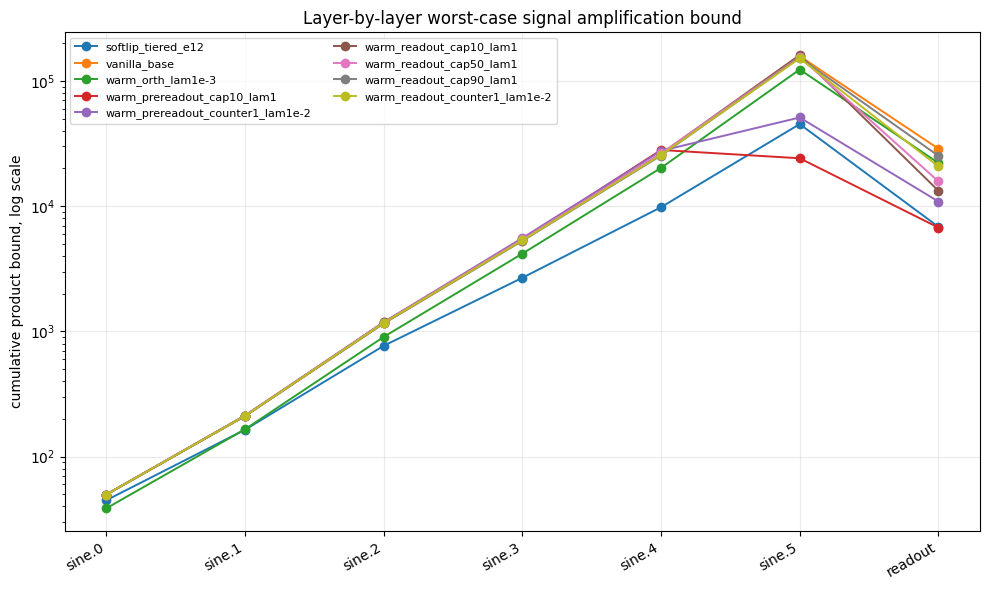

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
for model, g in layer_df.groupby('model'):
    g = g.copy()
    x = np.arange(len(g))
    ax.plot(x, g['cumulative_bound'], marker='o', linewidth=1.4, label=model)
ax.set_yscale('log')
ax.set_xticks(np.arange(len(layer_df['layer'].unique())))
ax.set_xticklabels(layer_df['layer'].drop_duplicates().tolist(), rotation=30, ha='right')
ax.set_ylabel('cumulative product bound, log scale')
ax.set_title('Layer-by-layer worst-case signal amplification bound')
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / 'layerwise_cumulative_amplification.png', dpi=180)
plt.show()

## Actual Activation Signal Through the SIREN

This cell traces a real forward pass through the spatial SIREN using zero phi. It records the RMS of the input, affine pre-activation, shifted pre-activation, sine output, and readout. This is complementary to the spectral bound above: the bound can be huge even when actual activations remain bounded by sine saturation.

In [11]:
from SIREN import SpatialModulatedINR


def build_model_from_ckpt(ckpt):
    args = ckpt['model_args']
    model = SpatialModulatedINR(
        height=args.get('height', 32),
        width=args.get('width', 32),
        hidden_features=args.get('hidden_dim', 256),
        num_layers=args.get('depth', 6),
        latent_spatial_dim=args.get('latent_spatial_dim', 8),
        latent_dim=args.get('latent_dim', 16),
        base_inr_type=args.get('inr_type', 'siren'),
        spatial_interp=args.get('spatial_interp', 'nearest'),
        use_local_coords=args.get('use_local_coords', True),
        modulation_type=args.get('modulation_type', 'shift'),
        freq=args.get('freq', 10.0),
        device='cpu',
        out_features=args.get('out_features', 3),
    )
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model


def rms(x):
    x = x.detach().float()
    return float(torch.sqrt(torch.mean(x ** 2)).item())


@torch.no_grad()
def trace_zero_phi_signal(label, relpath):
    ckpt, _ = load_checkpoint(relpath)
    model = build_model_from_ckpt(ckpt)
    phi = torch.zeros(*model.phi_shape)

    phi_flat = phi.reshape(-1, model.latent_dim)
    z_cell = phi_flat[model.flat_cell]
    shifts = model.modul(z_cell)

    x = model.local_coords if model.use_local_coords else model.meshgrid
    rows = []
    for idx, layer in enumerate(model.siren.net):
        shift = shifts[:, idx * model.hidden_features:(idx + 1) * model.hidden_features]
        z = layer.affine(x)
        z_shift = z + shift
        y = torch.sin(layer.freq * z_shift)
        rows.append(dict(
            model=label,
            layer=f'sine.{idx}',
            input_rms=rms(x),
            affine_rms=rms(z),
            shifted_rms=rms(z_shift),
            output_rms=rms(y),
            output_std=float(y.std().item()),
            output_absmax=float(y.abs().max().item()),
            rms_gain_vs_input=rms(y) / max(rms(x), 1e-12),
        ))
        x = y
    out = model.siren.hidden2rgb(x)
    rows.append(dict(
        model=label,
        layer='readout',
        input_rms=rms(x),
        affine_rms=rms(out),
        shifted_rms=np.nan,
        output_rms=rms(out),
        output_std=float(out.std().item()),
        output_absmax=float(out.abs().max().item()),
        rms_gain_vs_input=rms(out) / max(rms(x), 1e-12),
    ))
    return rows


trace_rows = []
for spec in MODELS:
    trace_rows.extend(trace_zero_phi_signal(spec['label'], spec['relpath']))

trace_df = pd.DataFrame(trace_rows)
trace_df.to_csv(OUT_DIR / 'zero_phi_activation_trace.csv', index=False)
trace_df

,model,layer,input_rms,affine_rms,shifted_rms,output_rms,output_std,output_absmax,rms_gain_vs_input
0,vanilla_base,sine.0,0.572822,0.233690,0.280213,0.700242,0.699650,1.000000,1.222443
1,vanilla_base,sine.1,0.700242,0.124414,0.188753,0.448114,0.447437,0.999999,0.639941
2,vanilla_base,sine.2,0.448114,0.120520,0.185007,0.457695,0.456988,0.999995,1.021381
3,vanilla_base,sine.3,0.457695,0.133767,0.200515,0.588602,0.587707,0.999999,1.286015
4,vanilla_base,sine.4,0.588602,0.182984,0.221117,0.685393,0.684169,1.000000,1.164441
...,...,...,...,...,...,...,...,...,...
58,warm_prereadout_counter1_lam1e-2,sine.2,0.449341,0.122525,0.187211,0.454398,0.454034,1.000000,1.011255
59,warm_prereadout_counter1_lam1e-2,sine.3,0.454398,0.129818,0.196558,0.572340,0.572068,0.999999,1.259555
60,warm_prereadout_counter1_lam1e-2,sine.4,0.572340,0.173345,0.215994,0.687841,0.686870,1.000000,1.201806
61,warm_prereadout_counter1_lam1e-2,sine.5,0.687841,0.110117,0.186665,0.736571,0.735979,1.000000,1.070845


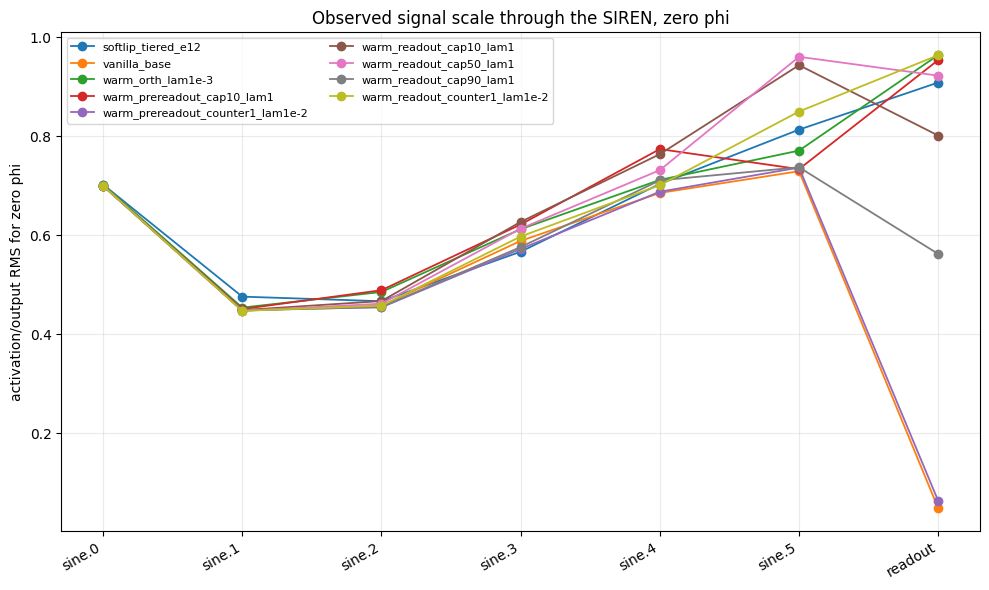

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for model, g in trace_df.groupby('model'):
    ax.plot(np.arange(len(g)), g['output_rms'], marker='o', linewidth=1.3, label=model)
ax.set_xticks(np.arange(len(trace_df['layer'].unique())))
ax.set_xticklabels(trace_df['layer'].drop_duplicates().tolist(), rotation=30, ha='right')
ax.set_ylabel('activation/output RMS for zero phi')
ax.set_title('Observed signal scale through the SIREN, zero phi')
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / 'zero_phi_activation_rms.png', dpi=180)
plt.show()

## Reading the Results

- The warm readout 90% cap is almost exactly satisfied, but that checkpoint only reached epoch 1.
- The stronger 50% and 10% readout caps are still violated, so the model did not fully converge to the intended cap.
- The final-sine 10% cap is also still violated, but less severely than the readout 10% cap.
- The counter-amplification caps are extremely small, so both counter runs remain far above the intended cap.
- The orthogonal run still has a large first-layer orthogonality penalty, so it did not really become orthonormal under this lambda/training setup.
- The cumulative amplification bound is much smaller for softlip tiered and prereadout cap10 than for vanilla, but that did not translate into clearly better PGD robustness in the current n=200 warm-start sweep.